In [ ]:
import pandas as pd

In [4]:
df=pd.read_csv("data.csv")
df

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,...,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,...,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,...,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,...,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,...,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,926424,M,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,...,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115,NaN
565,926682,M,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,...,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637,NaN
566,926954,M,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,...,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820,NaN
567,927241,M,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,...,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400,NaN


In [5]:
print(df.shape)
print(df.columns.tolist())

(569, 33)
['id', 'diagnosis', 'radius_mean', 'texture_mean', 'perimeter_mean', 'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean', 'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean', 'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se', 'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se', 'fractal_dimension_se', 'radius_worst', 'texture_worst', 'perimeter_worst', 'area_worst', 'smoothness_worst', 'compactness_worst', 'concavity_worst', 'concave points_worst', 'symmetry_worst', 'fractal_dimension_worst', 'Unnamed: 32']


In [6]:
print(df.isnull().sum())

id                           0
diagnosis                    0
radius_mean                  0
texture_mean                 0
perimeter_mean               0
area_mean                    0
smoothness_mean              0
compactness_mean             0
concavity_mean               0
concave points_mean          0
symmetry_mean                0
fractal_dimension_mean       0
radius_se                    0
texture_se                   0
perimeter_se                 0
area_se                      0
smoothness_se                0
compactness_se               0
concavity_se                 0
concave points_se            0
symmetry_se                  0
fractal_dimension_se         0
radius_worst                 0
texture_worst                0
perimeter_worst              0
area_worst                   0
smoothness_worst             0
compactness_worst            0
concavity_worst              0
concave points_worst         0
symmetry_worst               0
fractal_dimension_worst      0
Unnamed:

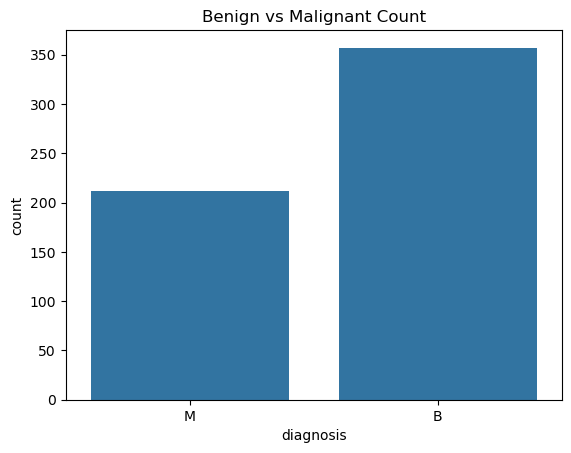

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='diagnosis', data=df)
plt.title('Benign vs Malignant Count')
plt.show()

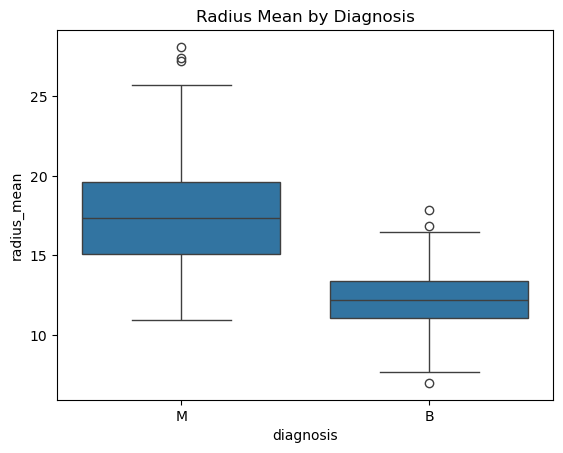

In [8]:
sns.boxplot(x='diagnosis', y='radius_mean', data=df)
plt.title('Radius Mean by Diagnosis')
plt.show()

In [12]:
df.drop(['id', 'Unnamed: 32'], axis=1, inplace=True)
df['diagnosis'] = df['diagnosis'].map({'M': 1, 'B': 0})


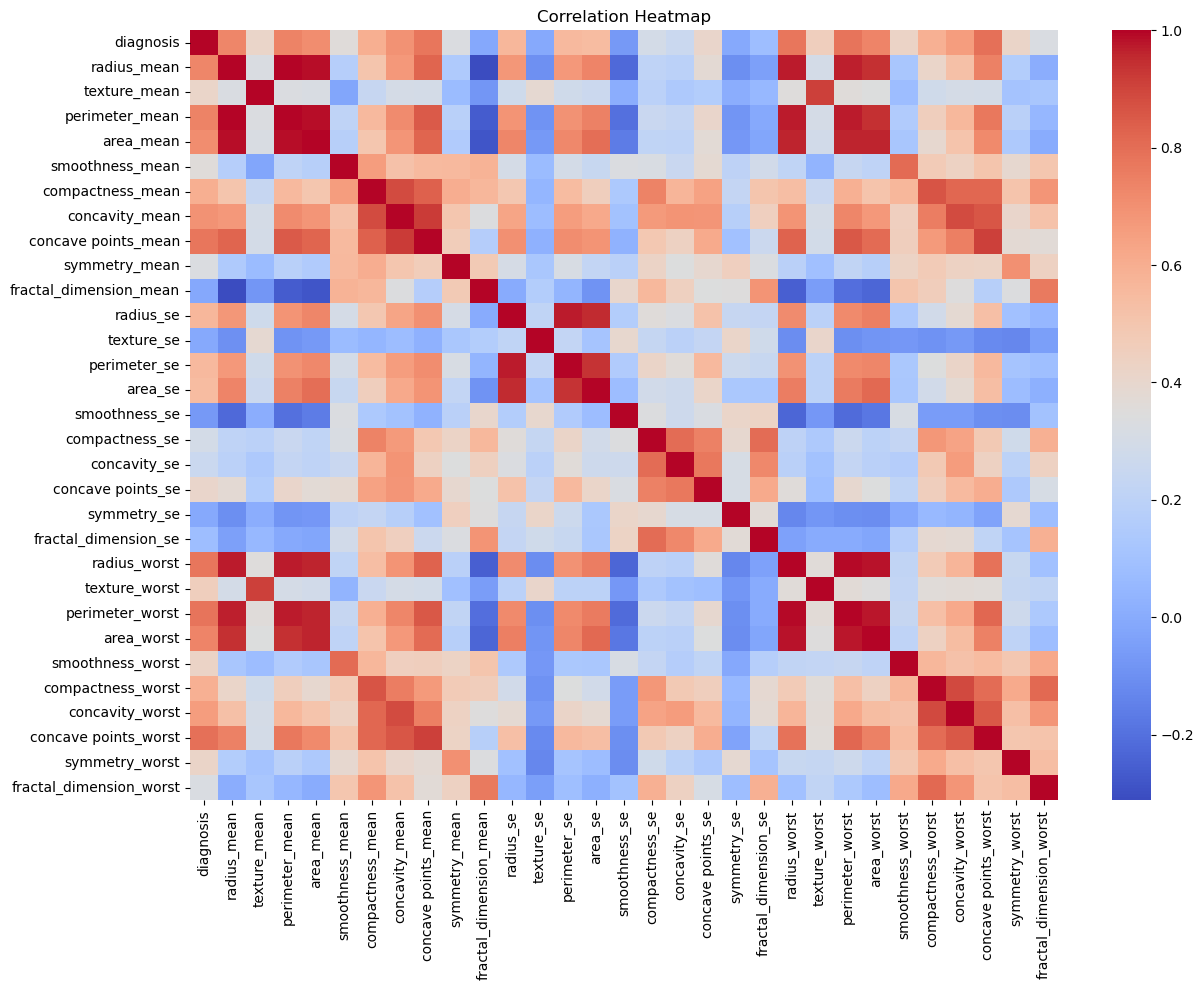

In [14]:
plt.figure(figsize=(14,10))
sns.heatmap(df.corr(), cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

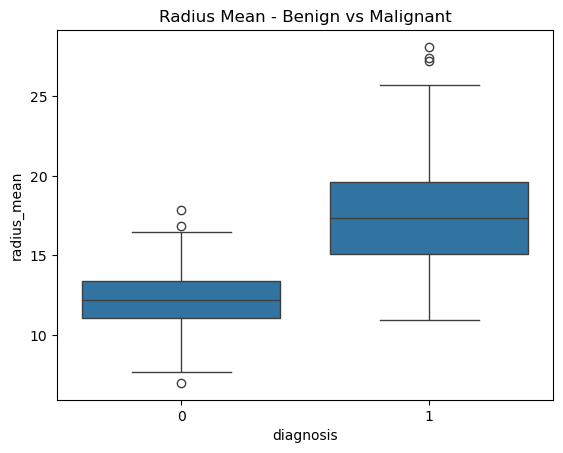

In [15]:
sns.boxplot(x='diagnosis', y='radius_mean', data=df)
plt.title('Radius Mean - Benign vs Malignant')
plt.show()

In [16]:
corr = df.corr()['diagnosis'].sort_values(ascending=False)
print(corr.head(11))

diagnosis               1.000000
concave points_worst    0.793566
perimeter_worst         0.782914
concave points_mean     0.776614
radius_worst            0.776454
perimeter_mean          0.742636
area_worst              0.733825
radius_mean             0.730029
area_mean               0.708984
concavity_mean          0.696360
concavity_worst         0.659610
Name: diagnosis, dtype: float64


In [17]:
# saperating the features 
X = df.drop('diagnosis', axis=1)
y = df['diagnosis']

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (569, 30)
y shape: (569,)


In [18]:
#scaling the features 
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Scaling done!")
print(X_scaled[0])

Scaling done!
[ 1.09706398 -2.07333501  1.26993369  0.9843749   1.56846633  3.28351467
  2.65287398  2.53247522  2.21751501  2.25574689  2.48973393 -0.56526506
  2.83303087  2.48757756 -0.21400165  1.31686157  0.72402616  0.66081994
  1.14875667  0.90708308  1.88668963 -1.35929347  2.30360062  2.00123749
  1.30768627  2.61666502  2.10952635  2.29607613  2.75062224  1.93701461]


In [19]:
# train test split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

print("Training size:", X_train.shape)
print("Testing size:", X_test.shape)

Training size: (455, 30)
Testing size: (114, 30)


In [20]:
df.shape

(569, 31)

In [21]:
df

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,1,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,0.2419,...,25.380,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890
1,1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,0.1812,...,24.990,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902
2,1,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,0.2069,...,23.570,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758
3,1,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,0.2597,...,14.910,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300
4,1,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,0.1809,...,22.540,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,1,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,0.1726,...,25.450,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115
565,1,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,0.1752,...,23.690,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637
566,1,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,0.1590,...,18.980,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820
567,1,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,0.2397,...,25.740,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400


In [22]:
df.to_csv('data_cleaned.csv', index=False)
print("Saved!")

Saved!


In [32]:
df.columns.tolist()
# Importing all necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, classification_report, 
                             confusion_matrix, ConfusionMatrixDisplay,
                             roc_curve, auc)
# Create and train the model
model = LogisticRegression(max_iter=10000, random_state=42)
model.fit(X_train, y_train)

print("Model training complete!")
print("Number of iterations taken:", model.n_iter_)

# Results
y_pred = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Model training complete!
Number of iterations taken: [21]
Accuracy: 0.9736842105263158
              precision    recall  f1-score   support

           0       0.97      0.99      0.98        71
           1       0.98      0.95      0.96        43

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114



In [31]:
# Predict on unseen test data
y_pred = model.predict(X_test)

# Also get probability scores (not just 0 or 1)
y_prob = model.predict_proba(X_test)[:, 1]

print("First 10 predictions:", y_pred[:10])
print("First 10 actual values:", y_test.values[:10])


First 10 predictions: [0 1 1 0 0 1 1 1 0 0]
First 10 actual values: [0 1 1 0 0 1 1 1 0 0]


In [ ]:
# Importing all necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, classification_report, 
                             confusion_matrix, ConfusionMatrixDisplay,
                             roc_curve, auc)


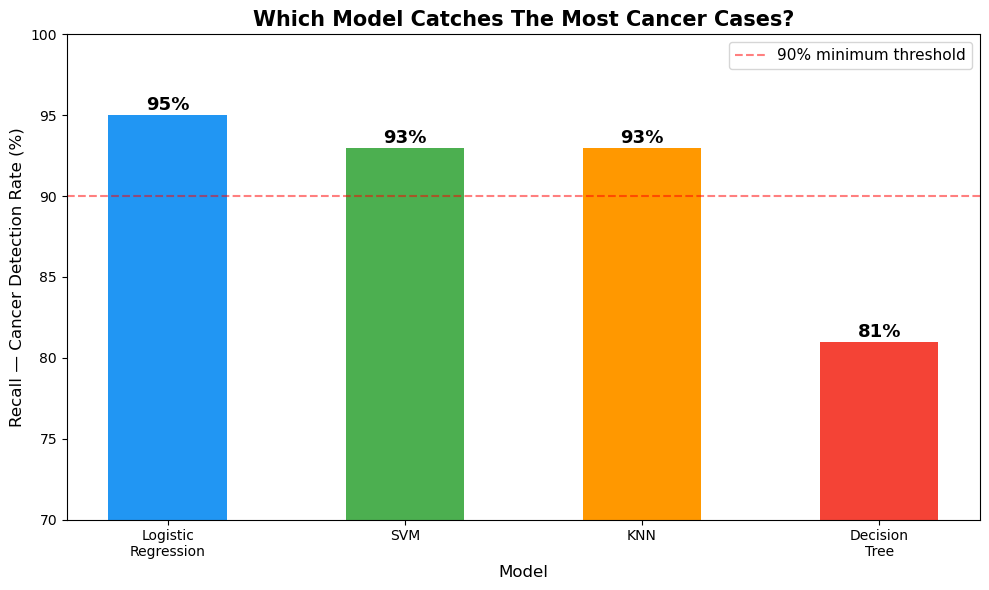

In [1]:
# Recall chart ( illustration )
import matplotlib.pyplot as plt

models = ['Logistic\nRegression', 'SVM', 'KNN', 'Decision\nTree']
recall  = [95, 93, 93, 81]
colors  = ['#2196F3', '#4CAF50', '#FF9800', '#F44336']

plt.figure(figsize=(10, 6))
bars = plt.bar(models, recall, color=colors, width=0.5)
plt.ylim([70, 100])
plt.title('Which Model Catches The Most Cancer Cases?',
          fontsize=15, fontweight='bold')
plt.ylabel('Recall — Cancer Detection Rate (%)', fontsize=12)
plt.xlabel('Model', fontsize=12)

for bar, val in zip(bars, recall):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.3,
             f'{val}%', ha='center', fontsize=13, 
             fontweight='bold')

plt.axhline(y=90, color='red', linestyle='--', 
            alpha=0.5, label='90% minimum threshold')
plt.legend(fontsize=11)
plt.tight_layout()
plt.savefig('recall_comparison.png')
plt.show()

In [3]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
import pandas as pd
import numpy as np

df = pd.read_csv('data.csv')
df.drop(['id', 'Unnamed: 32'], axis=1, inplace=True)
df['diagnosis'] = df['diagnosis'].map({'M': 1, 'B': 0})

X = df.drop('diagnosis', axis=1)
y = df['diagnosis']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42)

model = LogisticRegression(max_iter=10000, random_state=42)
model.fit(X_train, y_train)

print("scaler and model ready!")

scaler and model ready!


In [4]:
#Cancer outputs for different inputs
import numpy as np

patients = {
    'Patient 1 - Small Tumor': 
        [10.0, 14.0, 65.0, 300.0, 0.08, 0.05, 0.02, 0.01,
         0.17, 0.06, 0.2, 0.8, 1.5, 15.0, 0.004, 0.01,
         0.01, 0.003, 0.015, 0.003, 11.0, 18.0, 72.0,
         365.0, 0.10, 0.08, 0.05, 0.02, 0.25, 0.07],

    'Patient 2 - Medium Tumor': 
        [14.0, 20.0, 95.0, 600.0, 0.10, 0.12, 0.10, 0.06,
         0.19, 0.07, 0.5, 1.5, 3.0, 45.0, 0.007, 0.025,
         0.03, 0.008, 0.02, 0.004, 16.0, 26.0, 108.0,
         800.0, 0.13, 0.20, 0.22, 0.09, 0.31, 0.09],

    'Patient 3 - Large Tumor': 
        [20.0, 25.0, 135.0, 1200.0, 0.14, 0.25, 0.28, 0.16,
         0.22, 0.09, 0.9, 2.5, 6.0, 90.0, 0.013, 0.05,
         0.07, 0.018, 0.035, 0.007, 26.0, 35.0, 175.0,
         2000.0, 0.18, 0.40, 0.50, 0.22, 0.40, 0.12],

    'Patient 4 - Very Large Tumor': 
        [25.0, 30.0, 165.0, 2000.0, 0.16, 0.35, 0.40, 0.20,
         0.25, 0.10, 1.2, 3.0, 8.0, 120.0, 0.015, 0.07,
         0.09, 0.022, 0.04, 0.009, 30.0, 40.0, 200.0,
         2500.0, 0.20, 0.55, 0.65, 0.28, 0.45, 0.14]
}

print("="*55)
print("  CANCER OUTPUT FOR DIFFERENT PATIENT INPUTS")
print("="*55)

for name, values in patients.items():
    input_array = np.array(values).reshape(1, -1)
    input_scaled = scaler.transform(input_array)
    prediction = model.predict(input_scaled)[0]
    probability = model.predict_proba(input_scaled)[0]
    cancer_prob = probability[1] * 100
    result = "MALIGNANT 🔴" if prediction == 1 else "BENIGN 🟢"
    print(f"\n{name}")
    print(f"Result:             {result}")
    print(f"Cancer Probability: {cancer_prob:.1f}%")
    print(f"Benign Probability: {100 - cancer_prob:.1f}%")
    print("-"*55)

  CANCER OUTPUT FOR DIFFERENT PATIENT INPUTS

Patient 1 - Small Tumor
Result:             BENIGN 🟢
Cancer Probability: 0.0%
Benign Probability: 100.0%
-------------------------------------------------------

Patient 2 - Medium Tumor
Result:             BENIGN 🟢
Cancer Probability: 47.1%
Benign Probability: 52.9%
-------------------------------------------------------

Patient 3 - Large Tumor
Result:             MALIGNANT 🔴
Cancer Probability: 100.0%
Benign Probability: 0.0%
-------------------------------------------------------

Patient 4 - Very Large Tumor
Result:             MALIGNANT 🔴
Cancer Probability: 100.0%
Benign Probability: 0.0%
-------------------------------------------------------


/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [5]:
def predict_and_recommend(input_values, model, scaler):
    
    print("\n" + "="*55)
    print("    🎗️  BREAST CANCER PREDICTION SYSTEM")
    print("="*55)
    
    input_array = np.array(input_values).reshape(1, -1)
    input_scaled = scaler.transform(input_array)
    prediction = model.predict(input_scaled)[0]
    probability = model.predict_proba(input_scaled)[0]
    
    cancer_prob = probability[1] * 100
    benign_prob = probability[0] * 100
    
    print(f"\n📊 Probability Scores:")
    print(f"   Cancer (Malignant): {cancer_prob:.1f}%")
    print(f"   Benign:             {benign_prob:.1f}%")
    
    if prediction == 1:
        print(f"\n🔴 DIAGNOSIS: MALIGNANT")
        print(f"\n📋 Recommendation:")
        if cancer_prob >= 90:
            print("   ⚠️  HIGH RISK")
            print("   → See an oncologist immediately")
            print("   → Biopsy strongly recommended")
            print("   → Do not delay treatment")
        elif cancer_prob >= 70:
            print("   ⚠️  MODERATE RISK")
            print("   → Book appointment this week")
            print("   → Further imaging tests needed")
        else:
            print("   ⚠️  BORDERLINE")
            print("   → Get a second medical opinion")
            print("   → Follow up scan in 1 month")
    else:
        print(f"\n🟢 DIAGNOSIS: BENIGN")
        print(f"\n📋 Recommendation:")
        if benign_prob >= 90:
            print("   ✅ LOW RISK")
            print("   → Continue regular annual check-ups")
            print("   → Maintain healthy lifestyle")
        else:
            print("   ✅ LIKELY BENIGN")
            print("   → Follow up in 3 months")
            print("   → Monitor for any changes")
    
    print(f"\n⚠️  This tool supports diagnosis only.")
    print("   Always consult a qualified doctor.")
    print("="*55)


# Test on all 4 patients from Day 3
for name, values in patients.items():
    print(f"\n--- {name} ---")
    predict_and_recommend(values, model, scaler)


--- Patient 1 - Small Tumor ---

    🎗️  BREAST CANCER PREDICTION SYSTEM

📊 Probability Scores:
   Cancer (Malignant): 0.0%
   Benign:             100.0%

🟢 DIAGNOSIS: BENIGN

📋 Recommendation:
   ✅ LOW RISK
   → Continue regular annual check-ups
   → Maintain healthy lifestyle

⚠️  This tool supports diagnosis only.
   Always consult a qualified doctor.

--- Patient 2 - Medium Tumor ---

    🎗️  BREAST CANCER PREDICTION SYSTEM

📊 Probability Scores:
   Cancer (Malignant): 47.1%
   Benign:             52.9%

🟢 DIAGNOSIS: BENIGN

📋 Recommendation:
   ✅ LIKELY BENIGN
   → Follow up in 3 months
   → Monitor for any changes

⚠️  This tool supports diagnosis only.
   Always consult a qualified doctor.

--- Patient 3 - Large Tumor ---

    🎗️  BREAST CANCER PREDICTION SYSTEM

📊 Probability Scores:
   Cancer (Malignant): 100.0%
   Benign:             0.0%

🔴 DIAGNOSIS: MALIGNANT

📋 Recommendation:
   ⚠️  HIGH RISK
   → See an oncologist immediately
   → Biopsy strongly recommended
   → Do no

/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
